# Pricing dynamique — Reinforcement Learning
Notebook focalisé uniquement sur des algorithmes RL pour déterminer un multiplicateur de prix optimal à partir du jeu de données fourni. Algorithmes: REINFORCE, DQN, SARSA, Actor-Critic.

In [121]:
# Dépendances (décommentez si nécessaire)
# !pip install -q torch pandas scikit-learn matplotlib tqdm

In [122]:
# Dépendances (décommentez et exécutez si nécessaire)
# !pip install -q torch pandas scikit-learn matplotlib tqdm

In [123]:
# !pip install --upgrade pip

In [124]:
# !pip install -q scikit-learn

In [125]:
# !pip install -q torch 

In [126]:
# !pip install torch torchvision torchaudio

In [127]:
import os
import math
import random
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
import torch.optim as optim
from tqdm import trange
import matplotlib.pyplot as plt

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [128]:
# Charger les données
DATA_PATH = os.path.join('..','..','data','raw','dynamic_pricing.csv')
df = pd.read_csv(DATA_PATH)
print('Rows:', len(df))
df.head()

Rows: 1000


,Number_of_Riders,Number_of_Drivers,Location_Category,Customer_Loyalty_Status,Number_of_Past_Rides,Average_Ratings,Time_of_Booking,Vehicle_Type,Expected_Ride_Duration,Historical_Cost_of_Ride
0,90,45,Urban,Silver,13,4.47,Night,Premium,90,284.257273
1,58,39,Suburban,Silver,72,4.06,Evening,Economy,43,173.874753
2,42,31,Rural,Silver,0,3.99,Afternoon,Premium,76,329.795469
3,89,28,Rural,Regular,67,4.31,Afternoon,Premium,134,470.201232
4,78,22,Rural,Regular,74,3.77,Afternoon,Economy,149,579.681422


In [129]:
# Prétraitement: one-hot + standardisation
df_clean = df.copy()
cat_cols = ['Location_Category','Customer_Loyalty_Status','Time_of_Booking','Vehicle_Type']
df_dummy = pd.get_dummies(df_clean[cat_cols], drop_first=True)
num_cols = ['Number_of_Riders','Number_of_Drivers','Number_of_Past_Rides','Average_Ratings','Expected_Ride_Duration']
X_num = df_clean[num_cols].astype(float)
scaler = StandardScaler()
X_num_scaled = pd.DataFrame(scaler.fit_transform(X_num), columns=num_cols)
X = pd.concat([X_num_scaled, df_dummy.reset_index(drop=True)], axis=1)
base_price = df_clean['Historical_Cost_of_Ride'].values.astype(float)
print('Feature shape:', X.shape)

Feature shape: (1000, 13)


In [130]:
class PriceEnv:
    "A simple environment that iterates over dataset rows."
    def __init__(self, X, base_price, multipliers=[0.8,1.0,1.2,1.5], beta=4.0):
        self.X = X.values.astype(np.float32)
        self.base_price = base_price.astype(np.float32)
        self.multipliers = np.array(multipliers, dtype=np.float32)
        self.beta = beta
        self.n = len(self.base_price)
        self.idx = 0
        self.state_dim = self.X.shape[1]
        self.action_space_n = len(self.multipliers)
    def reset(self):
        self.idx = 0
        return self.X[self.idx].copy()
    def step(self, action):
        mult = float(self.multipliers[int(action)])
        base = float(self.base_price[self.idx]) if self.base_price[self.idx] > 0 else 1.0
        offered = base * mult
        ratio = offered / base
        p_accept = 1.0 / (1.0 + math.exp(self.beta * (ratio - 1.0)))
        accepted = np.random.rand() < p_accept
        reward = offered if accepted else 0.0
        self.idx += 1
        done = self.idx >= self.n
        next_state = self.X[self.idx].copy() if not done else np.zeros_like(self.X[0])
        return next_state, reward, done, {'accepted': accepted, 'p_accept': p_accept, 'offered': offered}
    def seed(self, s):
        np.random.seed(s)

In [131]:
# Split and create envs
X_df = X.copy()
X_train_df, X_test_df, bp_train, bp_test = train_test_split(X_df, base_price, test_size=0.2, random_state=SEED)
env_train = PriceEnv(X_train_df, bp_train)
env_test = PriceEnv(X_test_df, bp_test)
print('Train size:', len(bp_train), 'Test size:', len(bp_test))

Train size: 800 Test size: 200


In [132]:
def evaluate(env, model, n_runs=5):
    "Evaluate a policy or q-network. Supports actor-critic (probs,value) and nets returning logits/Q-values."
    totals = []
    for _ in range(n_runs):
        s = env.reset()
        done = False
        total = 0.0
        while not done:
            st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            with torch.no_grad():
                out = model(st)
            if isinstance(out, (tuple, list)):
                probs = out[0]
                arr = probs.cpu().numpy().ravel()
                action = int(np.argmax(arr))
            else:
                arr = out.cpu().numpy().ravel()
                action = int(np.argmax(arr))
            s, r, done, info = env.step(action)
            total += r
        totals.append(total)
    return float(np.mean(totals)), float(np.std(totals))

def plot_history(histories, labels, title='Training'):
    for h,l in zip(histories, labels):
        plt.plot(h, label=l)
    plt.legend()
    plt.title(title)
    plt.xlabel('Episode')
    plt.ylabel('Total reward')
    plt.show()

## REINFORCE (Policy Gradient) — définition et entraînement

In [133]:
class PolicyNet(nn.Module):
    def __init__(self, input_dim, n_actions, hidden=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        logits = self.net(x)
        return torch.softmax(logits, dim=-1)

def train_reinforce(env, input_dim, n_actions, epochs=40, gamma=0.99, lr=1e-3):
    policy = PolicyNet(input_dim, n_actions).to(device)
    opt = optim.Adam(policy.parameters(), lr=lr)
    history = []
    for ep in trange(epochs, desc='REINFORCE'):
        s = env.reset()
        log_probs = []
        rewards = []
        done = False
        while not done:
            st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            probs = policy(st)
            m = torch.distributions.Categorical(probs)
            action = int(m.sample().item())
            log_prob = m.log_prob(torch.tensor(action, device=device))
            ns, r, done, _ = env.step(action)
            log_probs.append(log_prob)
            rewards.append(r)
            s = ns
        # compute returns
        returns = []
        R = 0.0
        for r in reversed(rewards):
            R = r + gamma * R
            returns.insert(0, R)
        returns = torch.tensor(returns, dtype=torch.float32, device=device)
        if len(returns) > 1:
            returns = (returns - returns.mean()) / (returns.std() + 1e-8)
        loss = 0.0
        for lp, G in zip(log_probs, returns):
            loss = loss - lp * G
        opt.zero_grad()
        loss.backward()
        opt.step()
        history.append(sum(rewards))
    return policy, history

REINFORCE: 100%|██████████| 30/30 [00:15<00:00,  1.98it/s]


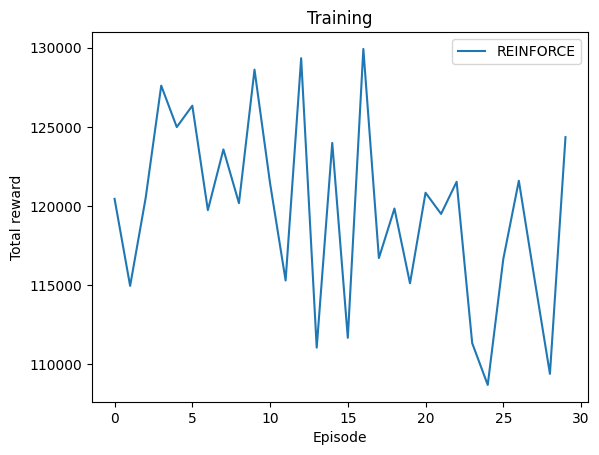

Mean revenue (REINFORCE): 40908.45 +/- 1197.20


In [134]:
# Run REINFORCE (fast demo)
policy_pg, hist_pg = train_reinforce(env_train, env_train.state_dim, env_train.action_space_n, epochs=30)
plot_history([hist_pg], ['REINFORCE'])
mean_pg, std_pg = evaluate(env_test, policy_pg, n_runs=8)
print(f'Mean revenue (REINFORCE): {mean_pg:.2f} +/- {std_pg:.2f}')

## DQN — définition et entraînement

In [135]:
from collections import deque, namedtuple
Transition = namedtuple('Transition', ('state','action','reward','next_state','done'))
class ReplayBuffer:
    def __init__(self, capacity=5000):
        self.buffer = deque(maxlen=capacity)
    def push(self, *args):
        self.buffer.append(Transition(*args))
    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        return Transition(*zip(*batch))
    def __len__(self):
        return len(self.buffer)

class QNet(nn.Module):
    def __init__(self, input_dim, n_actions, hidden=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
    def forward(self, x):
        return self.net(x)

In [136]:
def train_dqn(env, input_dim, n_actions, episodes=60, buffer_capacity=3000, batch_size=32, gamma=0.99, lr=1e-3, target_update=5):
    q_net = QNet(input_dim, n_actions).to(device)
    target_net = QNet(input_dim, n_actions).to(device)
    target_net.load_state_dict(q_net.state_dict())
    opt = optim.Adam(q_net.parameters(), lr=lr)
    buffer = ReplayBuffer(capacity=buffer_capacity)
    eps = 1.0; eps_end=0.05; eps_decay=0.995
    hist = []
    for ep in trange(episodes, desc='DQN'):
        s = env.reset()
        done=False; total=0.0
        while not done:
            if random.random() < eps:
                a = random.randrange(n_actions)
            else:
                with torch.no_grad():
                    qvals = q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))
                    a = int(torch.argmax(qvals).item())
            ns, r, done, _ = env.step(a)
            buffer.push(s, a, r, ns, done)
            s = ns; total += r
            if len(buffer) >= batch_size:
                batch = buffer.sample(batch_size)
                states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                actions = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
                rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)
                q_values = q_net(states).gather(1, actions)
                with torch.no_grad():
                    target_q = target_net(next_states).max(1)[0].unsqueeze(1)
                    expected = rewards_b + gamma * target_q * (1 - dones)
                loss = nn.MSELoss()(q_values, expected)
                opt.zero_grad(); loss.backward(); opt.step()
        eps = max(eps_end, eps*eps_decay)
        if ep % target_update == 0:
            target_net.load_state_dict(q_net.state_dict())
        hist.append(total)
    return q_net, hist

DQN: 100%|██████████| 40/40 [00:48<00:00,  1.22s/it]


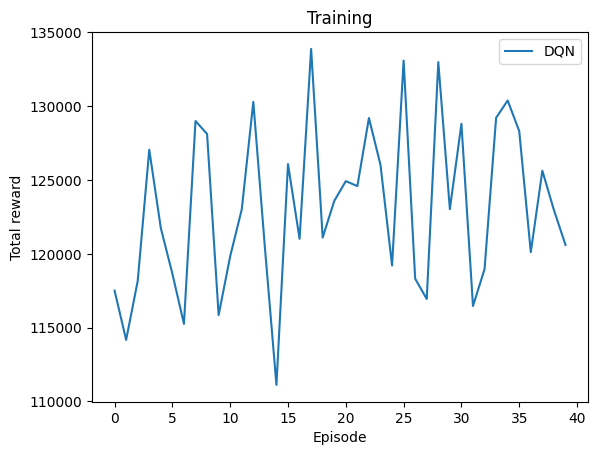

Mean revenue (DQN): 41190.87 +/- 2217.44


In [137]:
dqn_net, hist_dqn = train_dqn(env_train, env_train.state_dim, env_train.action_space_n, episodes=40)
plot_history([hist_dqn], ['DQN'])
mean_dqn, std_dqn = evaluate(env_test, dqn_net, n_runs=8)
print(f'Mean revenue (DQN): {mean_dqn:.2f} +/- {std_dqn:.2f}')

## SARSA — entraînement (on-policy)

In [138]:
def train_sarsa(env, input_dim, n_actions, episodes=40, gamma=0.99, lr=1e-3):
    q_net = QNet(input_dim, n_actions).to(device)
    opt = optim.Adam(q_net.parameters(), lr=lr)
    eps = 1.0; eps_end=0.05; eps_decay=0.995
    hist = []
    for ep in trange(episodes, desc='SARSA'):
        s = env.reset()
        if random.random() < eps:
            a = random.randrange(n_actions)
        else:
            with torch.no_grad():
                a = int(torch.argmax(q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))).item())
        done=False; total=0.0
        while not done:
            ns, r, done, _ = env.step(a)
            if random.random() < eps:
                na = random.randrange(n_actions)
            else:
                with torch.no_grad():
                    na = int(torch.argmax(q_net(torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0))).item())
            q_sa = q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))[0,a]
            with torch.no_grad():
                q_sna = q_net(torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0))[0,na]
            target = r + (0.0 if done else gamma * q_sna)
            loss = nn.MSELoss()(q_sa, torch.tensor(target, dtype=torch.float32, device=device))
            opt.zero_grad(); loss.backward(); opt.step()
            s = ns; a = na; total += r
        eps = max(eps_end, eps*eps_decay)
        hist.append(total)
    return q_net, hist

SARSA:   0%|          | 0/40 [00:00<?, ?it/s]C:\Users\yskon\AppData\Local\Temp\ipykernel_4748\3295585712.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = nn.MSELoss()(q_sa, torch.tensor(target, dtype=torch.float32, device=device))
SARSA: 100%|██████████| 40/40 [00:43<00:00,  1.08s/it]


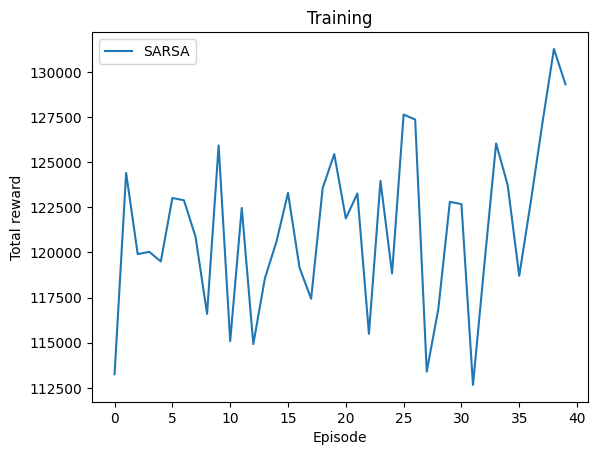

Mean revenue (SARSA): 35891.37 +/- 2426.43


In [139]:
sarsa_net, hist_sarsa = train_sarsa(env_train, env_train.state_dim, env_train.action_space_n, episodes=40)
plot_history([hist_sarsa], ['SARSA'])
mean_sarsa, std_sarsa = evaluate(env_test, sarsa_net, n_runs=8)
print(f'Mean revenue (SARSA): {mean_sarsa:.2f} +/- {std_sarsa:.2f}')

## Actor-Critic (Advantage) — définition et entraînement

In [140]:
class ActorCritic(nn.Module):
    def __init__(self, input_dim, n_actions, hidden=128):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.ReLU(),
        )
        self.actor = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, n_actions)
        )
        self.critic = nn.Sequential(
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, 1)
        )
    def forward(self, x):
        h = self.shared(x)
        logits = self.actor(h)
        value = self.critic(h).squeeze(-1)
        return torch.softmax(logits, dim=-1), value

def train_actor_critic(env, input_dim, n_actions, episodes=60, lr=3e-4, gamma=0.99):
    ac = ActorCritic(input_dim, n_actions).to(device)
    opt = optim.Adam(ac.parameters(), lr=lr)
    hist = []
    for ep in trange(episodes, desc='A2C'):
        s = env.reset(); done=False; ep_reward=0.0
        while not done:
            st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
            probs, value = ac(st)
            m = torch.distributions.Categorical(probs)
            a = int(m.sample().item())
            ns, r, done, _ = env.step(a)
            st_ns = torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0)
            _, value_ns = ac(st_ns)
            td_target = r + (0.0 if done else gamma * value_ns.item())
            advantage = td_target - value.item()
            a_log = torch.log(probs[0,a] + 1e-8)
            actor_loss = -a_log * advantage
            critic_loss = advantage**2
            loss = actor_loss + critic_loss
            opt.zero_grad(); loss.backward(); opt.step()
            s = ns; ep_reward += r
        hist.append(ep_reward)
    return ac, hist

A2C: 100%|██████████| 60/60 [01:26<00:00,  1.44s/it]


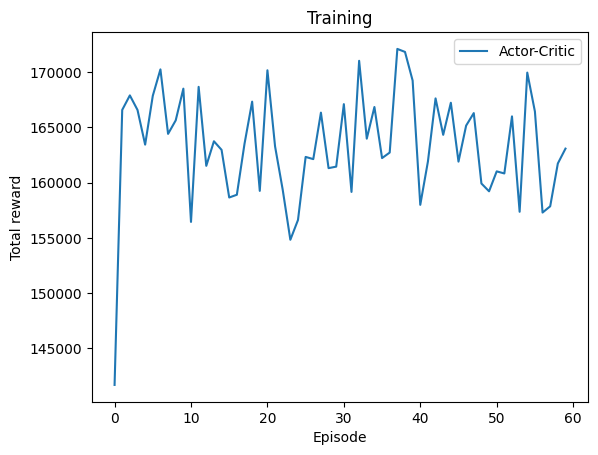

Mean revenue (Actor-Critic): 42241.29 +/- 2478.60


In [141]:
ac_net, hist_ac = train_actor_critic(env_train, env_train.state_dim, env_train.action_space_n, episodes=60)
plot_history([hist_ac], ['Actor-Critic'])
mean_ac, std_ac = evaluate(env_test, ac_net, n_runs=8)
print(f'Mean revenue (Actor-Critic): {mean_ac:.2f} +/- {std_ac:.2f}')

REINFORCE: mean=37379.65 std=1680.12
DQN: mean=41493.92 std=1318.24
SARSA: mean=36505.18 std=2466.67
AC: mean=42241.81 std=1780.68


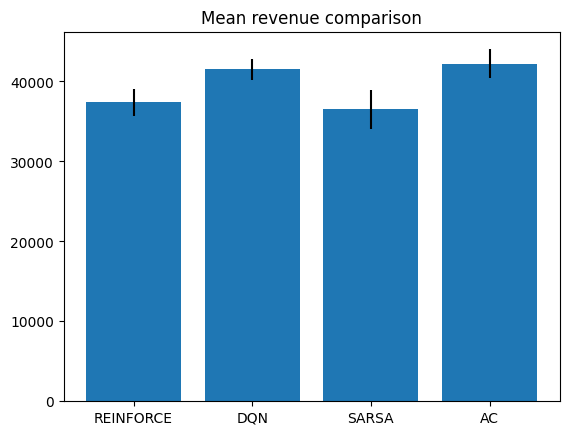

In [142]:
# Benchmark: comparer moyennes et tracer ensemble
results = {
    'REINFORCE': evaluate(env_test, policy_pg, n_runs=8),
    'DQN': evaluate(env_test, dqn_net, n_runs=8),
    'SARSA': evaluate(env_test, sarsa_net, n_runs=8),
    'AC': evaluate(env_test, ac_net, n_runs=8)
}
for k,(m,s) in results.items():
    print(f'{k}: mean={m:.2f} std={s:.2f}')
# quick bar plot
labels = list(results.keys())
means = [results[l][0] for l in labels]
errs = [results[l][1] for l in labels]
plt.bar(labels, means, yerr=errs); plt.title('Mean revenue comparison'); plt.show()

## Évaluation approfondie et baselines
Nous ajoutons des baselines simples (fixed multipliers, random) et une borne myope (espérance par-sample)
pour contextualiser les performances des agents RL et mesurer le regret par rapport à une heuristique optimale myope.

In [143]:
# Baselines: fixed policies, random, myopic expected revenue
multipliers = [0.8, 1.0, 1.2, 1.5]
def eval_fixed(env, action, n_runs=16, seed=SEED):
    totals = []
    for r in range(n_runs):
        env.seed(seed + r)
        s = env.reset()
        done = False
        total = 0.0
        while not done:
            s, reward, done, _ = env.step(action)
            total += reward
        totals.append(total)
    return float(np.mean(totals)), float(np.std(totals))
# compute baselines on test env
baselines = {}
for m in multipliers:
    idx = multipliers.index(m)
    baselines[f'fixed_{m}'] = eval_fixed(env_test, idx, n_runs=16)
# random policy
import random
def eval_random(env, n_runs=16, seed=SEED):
    totals = []
    for r in range(n_runs):
        random.seed(seed + r); np.random.seed(seed + r)
        s = env.reset(); done=False; total=0.0
        while not done:
            a = random.randrange(len(env.multipliers))
            s, reward, done, _ = env.step(a)
            total += reward
        totals.append(total)
    return float(np.mean(totals)), float(np.std(totals))
baselines['random'] = eval_random(env_test, n_runs=16)
# myopic expected (upper bound): choose action with max offered*p_accept per sample
def myopic_expected(bp_array, multipliers, beta=4.0):
    totals = []
    for b in bp_array:
        base = float(b) if b>0 else 1.0
        offered = np.array(multipliers) * base
        ratio = offered / base
        p_accept = 1.0 / (1.0 + np.exp(beta * (ratio - 1.0)))
        expected = offered * p_accept
        totals.append(np.max(expected))
    return float(np.sum(totals)), float(np.mean(totals))
sum_myopic, mean_myopic = myopic_expected(bp_test, multipliers, beta=env_test.beta)
baselines['myopic_expected_total'] = (sum_myopic, mean_myopic)
# show baselines
import pandas as _pd
df_baselines = _pd.DataFrame([{'policy':k, 'mean_total':v[0], 'std':v[1] if isinstance(v, tuple) and len(v)>1 else None} for k,v in baselines.items()])
print(df_baselines)
# combine with previously computed results dict if present
try:
    res_df = _pd.DataFrame([{'policy':k, 'mean_total':v[0], 'std':v[1]} for k,v in results.items()])
    summary = _pd.concat([res_df, df_baselines], ignore_index=True, sort=False)
    print('\nCombined results:')
    print(summary)
except Exception:
    pass

                  policy    mean_total          std
0              fixed_0.8  42400.321400  1530.566398
1              fixed_1.0  38690.681041  2442.592734
2              fixed_1.2  27620.047357  3130.171254
3              fixed_1.5  14417.164628  3492.450003
4                 random  31075.760986  3731.963389
5  myopic_expected_total  41905.724483   209.528622

Combined results:
                  policy    mean_total          std
0              REINFORCE  37379.652179  1680.117862
1                    DQN  41493.919943  1318.236662
2                  SARSA  36505.176132  2466.669809
3                     AC  42241.807541  1780.684635
4              fixed_0.8  42400.321400  1530.566398
5              fixed_1.0  38690.681041  2442.592734
6              fixed_1.2  27620.047357  3130.171254
7              fixed_1.5  14417.164628  3492.450003
8                 random  31075.760986  3731.963389
9  myopic_expected_total  41905.724483   209.528622


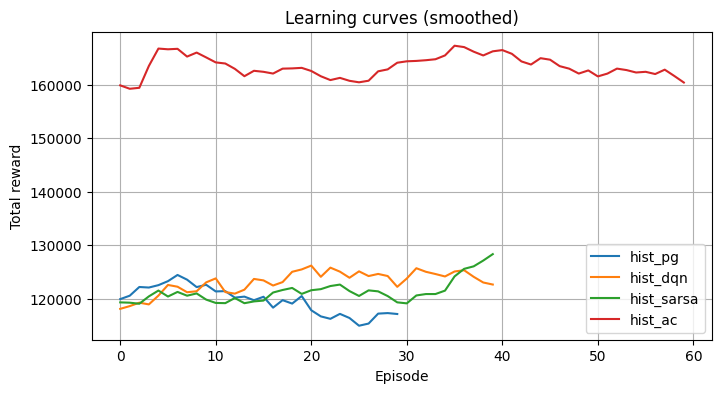

In [144]:
# Visualisations améliorées: courbes d'apprentissage lissées + intervalles
from scipy.ndimage import uniform_filter1d
def plot_training_curves(histories, labels, smooth=5):
    plt.figure(figsize=(8,4))
    for h,l in zip(histories, labels):
        ys = np.array(h)
        ys_s = uniform_filter1d(ys, size=smooth) if len(ys)>smooth else ys
        plt.plot(ys_s, label=l)
    plt.xlabel('Episode'); plt.ylabel('Total reward'); plt.title('Learning curves (smoothed)')
    plt.legend(); plt.grid(True); plt.show()
# example usage if hist_* variables exist
hc = [] ; labs = []
for name in ['hist_pg','hist_dqn','hist_sarsa','hist_ac']:
    if name in globals():
        hc.append(globals()[name]); labs.append(name)
if hc: plot_training_curves(hc, labs, smooth=7)

## Expérimentation reproducible et tuning rapide
Les fonctions ci-dessous permettent de lancer des runs plus longs, enregistrer l'historique et les modèles pour analyses ultérieures.

In [145]:
import os
def run_and_save_dqn(env, episodes=200, out_dir='experiments'):
    os.makedirs(out_dir, exist_ok=True)
    q_net, hist = train_dqn(env, env.state_dim, env.action_space_n, episodes=episodes)
    # save history and model
    import pickle
    with open(os.path.join(out_dir, 'dqn_hist.pkl'), 'wb') as f: pickle.dump(hist, f)
    torch.save(q_net.state_dict(), os.path.join(out_dir, 'dqn_model.pt'))
    return q_net, hist
# NOTE: pour PPO/A2C/SAC, installez stable-baselines3 et ajoutez scripts similaires (try/except below)
try:
    import stable_baselines3 as sb3
    _HAS_SB3 = True
except Exception:
    _HAS_SB3 = False
    print('stable-baselines3 non installé — pip install stable-baselines3[extra] pour tester PPO/A2C/SAC')

stable-baselines3 non installé — pip install stable-baselines3[extra] pour tester PPO/A2C/SAC


## Sauvegarde & prochaines étapes
- Sauvegarder modèles avec `torch.save(...)`.
- Tuning, utiliser Stable-Baselines3 pour PPO/A2C/SAC pour comparaisons plus sérieuses.

## Grid-search léger (automatisé)
Cellules utilitaires pour lancer un grid-search léger sur les hyperparamètres de chaque algorithme.
Attention: limite le nombre de combinaisons pour rester rapide (par défaut petites grilles).

In [146]:
import itertools, pickle, time

def grid_search_reinforce(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best = {'mean': -float('inf')}
    for lr, epochs, hidden in itertools.product(grid['lr'], grid['epochs'], grid.get('hidden',[64])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        # local train loop (parameterized) to avoid changing global train_reinforce signature
        policy = PolicyNet(input_dim, n_actions, hidden=hidden).to(device)
        opt = optim.Adam(policy.parameters(), lr=lr)
        hist = []
        for ep in range(epochs):
            s = env.reset(); done=False; log_probs=[]; rewards=[]
            while not done:
                st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                probs = policy(st)
                m = torch.distributions.Categorical(probs)
                a = int(m.sample().item())
                log_probs.append(m.log_prob(torch.tensor(a, device=device)))
                ns, r, done, _ = env.step(a)
                rewards.append(r); s = ns
            # returns
            R=0.0; returns=[]
            for r in reversed(rewards): R = r + 0.99*R; returns.insert(0, R)
            returns = torch.tensor(returns, dtype=torch.float32, device=device)
            if len(returns)>1: returns=(returns-returns.mean())/(returns.std()+1e-8)
            loss = 0.0
            for lp, G in zip(log_probs, returns): loss = loss - lp * G
            opt.zero_grad(); loss.backward(); opt.step()
            hist.append(sum(rewards))
        mean, std = evaluate(env, policy, n_runs=eval_runs)
        print(f'REINFORCE lr={lr} epochs={epochs} hidden={hidden} -> mean={mean:.2f} std={std:.2f}')
        if mean > best.get('mean', -float('inf')):
            best = {'mean': mean, 'std': std, 'lr': lr, 'epochs': epochs, 'hidden': hidden, 'policy': policy, 'hist': hist}
    return best


def grid_search_dqn(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best = {'mean': -float('inf')}
    for lr, episodes, hidden, batch_size in itertools.product(grid['lr'], grid['episodes'], grid.get('hidden',[128]), grid.get('batch_size',[32])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        q_net = QNet(input_dim, n_actions, hidden=hidden).to(device)
        target_net = QNet(input_dim, n_actions, hidden=hidden).to(device)
        target_net.load_state_dict(q_net.state_dict())
        opt = optim.Adam(q_net.parameters(), lr=lr)
        buffer = ReplayBuffer(capacity=grid.get('buffer_capacity',3000))
        eps=1.0; eps_end=0.05; eps_decay=0.995
        hist=[]
        for ep in range(episodes):
            s=env.reset(); done=False; total=0.0
            while not done:
                if random.random()<eps:
                    a=random.randrange(n_actions)
                else:
                    with torch.no_grad():
                        a=int(torch.argmax(q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))).item())
                ns, r, done, _ = env.step(a)
                buffer.push(s,a,r,ns,done)
                s=ns; total+=r
                if len(buffer)>=batch_size:
                    batch = buffer.sample(batch_size)
                    states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                    actions = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
                    rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                    next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                    dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)
                    q_values = q_net(states).gather(1, actions)
                    with torch.no_grad():
                        target_q = target_net(next_states).max(1)[0].unsqueeze(1)
                        expected = rewards_b + 0.99 * target_q * (1 - dones)
                    loss = nn.MSELoss()(q_values, expected)
                    opt.zero_grad(); loss.backward(); opt.step()
            eps = max(eps_end, eps*eps_decay)
            if ep % grid.get('target_update',5)==0: target_net.load_state_dict(q_net.state_dict())
            hist.append(total)
        mean, std = evaluate(env, q_net, n_runs=eval_runs)
        print(f'DQN lr={lr} episodes={episodes} hidden={hidden} batch={batch_size} -> mean={mean:.2f}')
        if mean > best.get('mean', -float('inf')): best = {'mean':mean,'std':std,'lr':lr,'episodes':episodes,'hidden':hidden,'batch_size':batch_size,'net':q_net,'hist':hist}
    return best


def grid_search_sarsa(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best={'mean':-float('inf')}
    for lr, episodes, hidden in itertools.product(grid['lr'], grid['episodes'], grid.get('hidden',[128])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        q_net = QNet(input_dim, n_actions, hidden=hidden).to(device)
        opt = optim.Adam(q_net.parameters(), lr=lr)
        eps=1.0; eps_end=0.05; eps_decay=0.995; hist=[]
        for ep in range(episodes):
            s=env.reset(); a = random.randrange(n_actions) if random.random()<eps else int(torch.argmax(q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))).item())
            done=False; total=0.0
            while not done:
                ns, r, done, _ = env.step(a)
                if random.random()<eps: na=random.randrange(n_actions)
                else: na=int(torch.argmax(q_net(torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0))).item())
                q_sa = q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))[0,a]
                with torch.no_grad(): q_sna = q_net(torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0))[0,na]
                target = r + (0.0 if done else 0.99 * q_sna)
                loss = nn.MSELoss()(q_sa, torch.tensor(target, dtype=torch.float32, device=device))
                opt.zero_grad(); loss.backward(); opt.step()
                s=ns; a=na; total+=r
            eps = max(eps_end, eps*eps_decay); hist.append(total)
        mean,std = evaluate(env, q_net, n_runs=eval_runs)
        print(f'SARSA lr={lr} episodes={episodes} hidden={hidden} -> mean={mean:.2f}')
        if mean>best.get('mean',-float('inf')): best={'mean':mean,'std':std,'lr':lr,'episodes':episodes,'hidden':hidden,'net':q_net,'hist':hist}
    return best


def grid_search_ac(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best={'mean':-float('inf')}
    for lr, episodes, hidden in itertools.product(grid['lr'], grid['episodes'], grid.get('hidden',[128])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        ac = ActorCritic(input_dim, n_actions, hidden=hidden).to(device)
        opt = optim.Adam(ac.parameters(), lr=lr)
        hist=[]
        for ep in range(episodes):
            s=env.reset(); done=False; ep_reward=0.0
            while not done:
                st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                probs, value = ac(st)
                m = torch.distributions.Categorical(probs)
                a = int(m.sample().item())
                ns, r, done, _ = env.step(a)
                st_ns = torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0)
                _, value_ns = ac(st_ns)
                td_target = r + (0.0 if done else 0.99 * value_ns.item())
                advantage = td_target - value.item()
                a_log = torch.log(probs[0,a] + 1e-8)
                actor_loss = -a_log * advantage; critic_loss = advantage**2; loss = actor_loss + critic_loss
                opt.zero_grad(); loss.backward(); opt.step()
                s=ns; ep_reward+=r
            hist.append(ep_reward)
        mean,std = evaluate(env, ac, n_runs=eval_runs)
        print(f'AC lr={lr} episodes={episodes} hidden={hidden} -> mean={mean:.2f}')
        if mean>best.get('mean',-float('inf')): best={'mean':mean,'std':std,'lr':lr,'episodes':episodes,'hidden':hidden,'model':ac,'hist':hist}
    return best


def run_light_grid_all(env_train, env_test, input_dim, n_actions, out_file='experiments/grid_results.pkl'):
    # small default grids (quick) - increase if you have time
    grids = {
        'reinforce': {'lr':[1e-3,5e-4], 'epochs':[30,60], 'hidden':[64]},
        'dqn': {'lr':[1e-3,5e-4], 'episodes':[40,80], 'hidden':[128], 'batch_size':[32,64]},
        'sarsa': {'lr':[1e-3,5e-4], 'episodes':[40,80], 'hidden':[128]},
        'ac': {'lr':[3e-4,1e-3], 'episodes':[60,120], 'hidden':[128]}
    }
    results = {}
    print('Grid REINFORCE...')
    results['reinforce'] = grid_search_reinforce(env_train, input_dim, n_actions, grids['reinforce'], eval_runs=8)
    print('Grid DQN...')
    results['dqn'] = grid_search_dqn(env_train, input_dim, n_actions, grids['dqn'], eval_runs=8)
    print('Grid SARSA...')
    results['sarsa'] = grid_search_sarsa(env_train, input_dim, n_actions, grids['sarsa'], eval_runs=8)
    print('Grid AC...')
    results['ac'] = grid_search_ac(env_train, input_dim, n_actions, grids['ac'], eval_runs=8)
    os.makedirs(os.path.dirname(out_file) or '.', exist_ok=True)
    with open(out_file, 'wb') as f: pickle.dump(results, f)
    print('Saved grid results to', out_file)
    return results

In [147]:
# Cell: corrected grid-search utilities (duplicate safe copy)
import itertools, pickle, time

def grid_search_reinforce(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best = {'mean': -float('inf')}
    for lr, epochs, hidden in itertools.product(grid['lr'], grid['epochs'], grid.get('hidden',[64])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        policy = PolicyNet(input_dim, n_actions, hidden=hidden).to(device)
        opt = optim.Adam(policy.parameters(), lr=lr)
        hist = []
        for ep in range(epochs):
            s = env.reset(); done=False; log_probs=[]; rewards=[]
            while not done:
                st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                probs = policy(st)
                m = torch.distributions.Categorical(probs)
                a = int(m.sample().item())
                log_probs.append(m.log_prob(torch.tensor(a, device=device)))
                ns, r, done, _ = env.step(a)
                rewards.append(r); s = ns
            R=0.0; returns=[]
            for r in reversed(rewards): R = r + 0.99*R; returns.insert(0, R)
            returns = torch.tensor(returns, dtype=torch.float32, device=device)
            if len(returns)>1: returns=(returns-returns.mean())/(returns.std()+1e-8)
            loss = 0.0
            for lp, G in zip(log_probs, returns): loss = loss - lp * G
            opt.zero_grad(); loss.backward(); opt.step()
            hist.append(sum(rewards))
        mean, std = evaluate(env, policy, n_runs=eval_runs)
        print(f'REINFORCE lr={lr} epochs={epochs} hidden={hidden} -> mean={mean:.2f} std={std:.2f}')
        if mean > best.get('mean', -float('inf')):
            best = {'mean': mean, 'std': std, 'lr': lr, 'epochs': epochs, 'hidden': hidden, 'policy': policy, 'hist': hist}
    return best


def grid_search_dqn(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best = {'mean': -float('inf')}
    for lr, episodes, hidden, batch_size in itertools.product(grid['lr'], grid['episodes'], grid.get('hidden',[128]), grid.get('batch_size',[32])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        q_net = QNet(input_dim, n_actions, hidden=hidden).to(device)
        target_net = QNet(input_dim, n_actions, hidden=hidden).to(device)
        target_net.load_state_dict(q_net.state_dict())
        opt = optim.Adam(q_net.parameters(), lr=lr)
        buffer = ReplayBuffer(capacity=grid.get('buffer_capacity',3000))
        eps=1.0; eps_end=0.05; eps_decay=0.995
        hist=[]
        for ep in range(episodes):
            s=env.reset(); done=False; total=0.0
            while not done:
                if random.random()<eps:
                    a=random.randrange(n_actions)
                else:
                    with torch.no_grad():
                        a=int(torch.argmax(q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))).item())
                ns, r, done, _ = env.step(a)
                buffer.push(s,a,r,ns,done)
                s=ns; total+=r
                if len(buffer)>=batch_size:
                    batch = buffer.sample(batch_size)
                    states = torch.tensor(np.array(batch.state), dtype=torch.float32, device=device)
                    actions = torch.tensor(batch.action, dtype=torch.long, device=device).unsqueeze(1)
                    rewards_b = torch.tensor(batch.reward, dtype=torch.float32, device=device).unsqueeze(1)
                    next_states = torch.tensor(np.array(batch.next_state), dtype=torch.float32, device=device)
                    dones = torch.tensor(batch.done, dtype=torch.float32, device=device).unsqueeze(1)
                    q_values = q_net(states).gather(1, actions)
                    with torch.no_grad():
                        target_q = target_net(next_states).max(1)[0].unsqueeze(1)
                        expected = rewards_b + 0.99 * target_q * (1 - dones)
                    loss = nn.MSELoss()(q_values, expected)
                    opt.zero_grad(); loss.backward(); opt.step()
            eps = max(eps_end, eps*eps_decay)
            if ep % grid.get('target_update',5)==0: target_net.load_state_dict(q_net.state_dict())
            hist.append(total)
        mean, std = evaluate(env, q_net, n_runs=eval_runs)
        print(f'DQN lr={lr} episodes={episodes} hidden={hidden} batch={batch_size} -> mean={mean:.2f}')
        if mean > best.get('mean', -float('inf')): best = {'mean':mean,'std':std,'lr':lr,'episodes':episodes,'hidden':hidden,'batch_size':batch_size,'net':q_net,'hist':hist}
    return best


def grid_search_sarsa(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best={'mean':-float('inf')}
    for lr, episodes, hidden in itertools.product(grid['lr'], grid['episodes'], grid.get('hidden',[128])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        q_net = QNet(input_dim, n_actions, hidden=hidden).to(device)
        opt = optim.Adam(q_net.parameters(), lr=lr)
        eps=1.0; eps_end=0.05; eps_decay=0.995; hist=[]
        for ep in range(episodes):
            s=env.reset(); a = random.randrange(n_actions) if random.random()<eps else int(torch.argmax(q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))).item())
            done=False; total=0.0
            while not done:
                ns, r, done, _ = env.step(a)
                if random.random()<eps: na=random.randrange(n_actions)
                else: na=int(torch.argmax(q_net(torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0))).item())
                q_sa = q_net(torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0))[0,a]
                with torch.no_grad(): q_sna = q_net(torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0))[0,na]
                target = r + (0.0 if done else 0.99 * q_sna)
                loss = nn.MSELoss()(q_sa, torch.tensor(target, dtype=torch.float32, device=device))
                opt.zero_grad(); loss.backward(); opt.step()
                s=ns; a=na; total+=r
            eps = max(eps_end, eps*eps_decay); hist.append(total)
        mean,std = evaluate(env, q_net, n_runs=eval_runs)
        print(f'SARSA lr={lr} episodes={episodes} hidden={hidden} -> mean={mean:.2f}')
        if mean>best.get('mean',-float('inf')): best={'mean':mean,'std':std,'lr':lr,'episodes':episodes,'hidden':hidden,'net':q_net,'hist':hist}
    return best


def grid_search_ac(env, input_dim, n_actions, grid, eval_runs=8, seed=SEED):
    best={'mean':-float('inf')}
    for lr, episodes, hidden in itertools.product(grid['lr'], grid['episodes'], grid.get('hidden',[128])):
        torch.manual_seed(seed); np.random.seed(seed); random.seed(seed)
        ac = ActorCritic(input_dim, n_actions, hidden=hidden).to(device)
        opt = optim.Adam(ac.parameters(), lr=lr)
        hist=[]
        for ep in range(episodes):
            s=env.reset(); done=False; ep_reward=0.0
            while not done:
                st = torch.tensor(s, dtype=torch.float32, device=device).unsqueeze(0)
                probs, value = ac(st)
                m = torch.distributions.Categorical(probs)
                a = int(m.sample().item())
                ns, r, done, _ = env.step(a)
                st_ns = torch.tensor(ns, dtype=torch.float32, device=device).unsqueeze(0)
                _, value_ns = ac(st_ns)
                td_target = r + (0.0 if done else 0.99 * value_ns.item())
                advantage = td_target - value.item()
                a_log = torch.log(probs[0,a] + 1e-8)
                actor_loss = -a_log * advantage; critic_loss = advantage**2; loss = actor_loss + critic_loss
                opt.zero_grad(); loss.backward(); opt.step()
                s=ns; ep_reward+=r
            hist.append(ep_reward)
        mean,std = evaluate(env, ac, n_runs=eval_runs)
        print(f'AC lr={lr} episodes={episodes} hidden={hidden} -> mean={mean:.2f}')
        if mean>best.get('mean',-float('inf')): best={'mean':mean,'std':std,'lr':lr,'episodes':episodes,'hidden':hidden,'model':ac,'hist':hist}
    return best


def run_light_grid_all(env_train, env_test, input_dim, n_actions, out_file='experiments/grid_results.pkl'):
    # small default grids (quick) - increase if you have time
    grids = {
        'reinforce': {'lr':[1e-3,5e-4], 'epochs':[30,60], 'hidden':[64]},
        'dqn': {'lr':[1e-3,5e-4], 'episodes':[40,80], 'hidden':[128], 'batch_size':[32,64]},
        'sarsa': {'lr':[1e-3,5e-4], 'episodes':[40,80], 'hidden':[128]},
        'ac': {'lr':[3e-4,1e-3], 'episodes':[60,120], 'hidden':[128]}
    }
    results = {}
    print('Grid REINFORCE...')
    results['reinforce'] = grid_search_reinforce(env_train, input_dim, n_actions, grids['reinforce'], eval_runs=8)
    print('Grid DQN...')
    results['dqn'] = grid_search_dqn(env_train, input_dim, n_actions, grids['dqn'], eval_runs=8)
    print('Grid SARSA...')
    results['sarsa'] = grid_search_sarsa(env_train, input_dim, n_actions, grids['sarsa'], eval_runs=8)
    print('Grid AC...')
    results['ac'] = grid_search_ac(env_train, input_dim, n_actions, grids['ac'], eval_runs=8)
    os.makedirs(os.path.dirname(out_file) or '.', exist_ok=True)
    with open(out_file, 'wb') as f: pickle.dump(results, f)
    print('Saved grid results to', out_file)
    return results

In [148]:
# Run the light grid-search (attention: execution potentiellement longue)
out_file = 'experiments/grid_results.pkl'
try:
    results = run_light_grid_all(env_train, env_test, env_train.state_dim, env_train.action_space_n, out_file=out_file)
    print('\nRésumé rapide des meilleurs résultats:')
    for k,v in results.items():
        params = {key:v.get(key) for key in ('lr','epochs','episodes','hidden','batch_size') if key in v}
        print(f"{k.upper()}: mean={v.get('mean'):.2f} std={v.get('std', None)} params={params}")
    print('\nRésultats sauvegardés dans:', out_file)
except Exception as e:
    print('Grid-search failed:', e)

Grid REINFORCE...
REINFORCE lr=0.001 epochs=30 hidden=64 -> mean=155086.97 std=4005.63
REINFORCE lr=0.001 epochs=60 hidden=64 -> mean=163131.42 std=4535.57
REINFORCE lr=0.0005 epochs=30 hidden=64 -> mean=138588.62 std=4599.57
REINFORCE lr=0.0005 epochs=60 hidden=64 -> mean=150045.74 std=5833.01
Grid DQN...
DQN lr=0.001 episodes=40 hidden=128 batch=32 -> mean=160409.60
DQN lr=0.001 episodes=40 hidden=128 batch=64 -> mean=158287.34
DQN lr=0.001 episodes=80 hidden=128 batch=32 -> mean=161792.40
DQN lr=0.001 episodes=80 hidden=128 batch=64 -> mean=158316.11
DQN lr=0.0005 episodes=40 hidden=128 batch=32 -> mean=153955.13
DQN lr=0.0005 episodes=40 hidden=128 batch=64 -> mean=162763.16
DQN lr=0.0005 episodes=80 hidden=128 batch=32 -> mean=161881.62
DQN lr=0.0005 episodes=80 hidden=128 batch=64 -> mean=159695.59
Grid SARSA...


C:\Users\yskon\AppData\Local\Temp\ipykernel_4748\1748277770.py:97: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  loss = nn.MSELoss()(q_sa, torch.tensor(target, dtype=torch.float32, device=device))


SARSA lr=0.001 episodes=40 hidden=128 -> mean=164140.40
SARSA lr=0.001 episodes=80 hidden=128 -> mean=163710.27
SARSA lr=0.0005 episodes=40 hidden=128 -> mean=164140.40
SARSA lr=0.0005 episodes=80 hidden=128 -> mean=163710.27
Grid AC...
AC lr=0.0003 episodes=60 hidden=128 -> mean=165246.21
AC lr=0.0003 episodes=120 hidden=128 -> mean=165655.41
AC lr=0.001 episodes=60 hidden=128 -> mean=165246.21
AC lr=0.001 episodes=120 hidden=128 -> mean=165655.41
Saved grid results to experiments/grid_results.pkl

Résumé rapide des meilleurs résultats:
REINFORCE: mean=163131.42 std=4535.571792253145 params={'lr': 0.001, 'epochs': 60, 'hidden': 64}
DQN: mean=162763.16 std=3730.8991818968166 params={'lr': 0.0005, 'episodes': 40, 'hidden': 128, 'batch_size': 64}
SARSA: mean=164140.40 std=3476.2950597444888 params={'lr': 0.001, 'episodes': 40, 'hidden': 128}
AC: mean=165655.41 std=4101.479081651633 params={'lr': 0.0003, 'episodes': 120, 'hidden': 128}

Résultats sauvegardés dans: experiments/grid_results

In [149]:
# Analyse des résultats et sélection du meilleur (chargement de experiments/grid_results.pkl)
import pickle, json, os
out_file = 'experiments/grid_results.pkl'
if not os.path.exists(out_file):
    print('Fichier introuvable:', out_file)
else:
    with open(out_file,'rb') as f: results = pickle.load(f)
    summary = {}
    for algo, r in results.items():
        mean = r.get('mean') if isinstance(r, dict) else None
        std = r.get('std') if isinstance(r, dict) else None
        params = {k:r.get(k) for k in ('lr','epochs','episodes','hidden','batch_size') if isinstance(r, dict) and k in r}
        summary[algo] = {'mean':mean, 'std':std, 'params':params}
    print('Résumé par algorithme:')
    for algo, v in summary.items():
        print(f"- {algo.upper()}: mean={v['mean']:.2f} std={v['std']} params={v['params']}")
    # choisir meilleur
    best_algo = max((a for a in summary.keys() if summary[a]['mean'] is not None), key=lambda a: summary[a]['mean'])
    best = summary[best_algo]
    print('\nMeilleur candidat:', best_algo.upper(), '->', best)
    os.makedirs('experiments', exist_ok=True)
    with open('experiments/best_candidate.json','w',encoding='utf-8') as f: json.dump({'best_algo':best_algo,'best':best,'summary':summary}, f, indent=2, ensure_ascii=False)
    print('Saved experiments/best_candidate.json')

Résumé par algorithme:
- REINFORCE: mean=163131.42 std=4535.571792253145 params={'lr': 0.001, 'epochs': 60, 'hidden': 64}
- DQN: mean=162763.16 std=3730.8991818968166 params={'lr': 0.0005, 'episodes': 40, 'hidden': 128, 'batch_size': 64}
- SARSA: mean=164140.40 std=3476.2950597444888 params={'lr': 0.001, 'episodes': 40, 'hidden': 128}
- AC: mean=165655.41 std=4101.479081651633 params={'lr': 0.0003, 'episodes': 120, 'hidden': 128}

Meilleur candidat: AC -> {'mean': 165655.41044422693, 'std': 4101.479081651633, 'params': {'lr': 0.0003, 'episodes': 120, 'hidden': 128}}
Saved experiments/best_candidate.json


In [150]:
# Évaluations détaillées (ré-évaluer les modèles candidats avec plusieurs runs)
import pickle, json
from copy import deepcopy
import numpy as _np

def re_eval_model(algo_key, model_dict, env_template, n_runs=30):
    # récupère l'objet modèle s'il est sauvegardé dans le dict (policy/net/model)
    model_obj = None
    for k in ('policy','net','model'):
        if isinstance(model_dict, dict) and k in model_dict: model_obj = model_dict[k]; break
    if model_obj is None:
        print('Aucun modèle enregistré pour', algo_key); return None
    samples = []
    for r in range(n_runs):
        env = deepcopy(env_template)
        env.seed(SEED + r)
        # evaluate returns (mean,std) over n_runs; we call with n_runs=1 to get a single episode total
        val, _ = evaluate(env, model_obj, n_runs=1)
        samples.append(float(val))
    return samples

# charger results si besoin
if 'results' not in globals():
    with open('experiments/grid_results.pkl','rb') as f: results = pickle.load(f)

# ré-évaluer chaque meilleur candidat trouvé dans results
eval_runs = 30
robust = {}
for algo, info in results.items():
    print('\nRe-eval pour', algo)
    samples = re_eval_model(algo, info, env_test, n_runs=eval_runs)
    if samples is None: continue
    robust[algo] = {'samples': samples, 'mean': float(_np.mean(samples)), 'std': float(_np.std(samples))}
    print(f"{algo.upper()}: mean={robust[algo]['mean']:.2f} std={robust[algo]['std']:.2f}")

# Tests statistiques pairés (t-test) entre le meilleur global et les autres
try:
    from scipy import stats
    best_algo = max(robust.keys(), key=lambda a: robust[a]['mean'])
    print('\nComparaisons (paired t-test) contre', best_algo.upper())
    for a,v in robust.items():
        if a==best_algo: continue
        t,p = stats.ttest_rel(robust[best_algo]['samples'], v['samples'])
        print(f"{best_algo.upper()} vs {a.upper()}: t={t:.3f} p={p:.4f}")
except Exception as e:
    print('scipy non dispo ou erreur:', e)
    print('Skipping t-test; installez scipy pour tests appariés')

# sauvegarder résultats robustes
with open('experiments/robust_results.json','w',encoding='utf-8') as f: json.dump(robust, f, indent=2, ensure_ascii=False)
print('Saved experiments/robust_results.json')


Re-eval pour reinforce
REINFORCE: mean=42096.62 std=1907.62

Re-eval pour dqn
DQN: mean=42370.32 std=1979.56

Re-eval pour sarsa
SARSA: mean=42690.05 std=2006.77

Re-eval pour ac
AC: mean=42690.05 std=2006.77

Comparaisons (paired t-test) contre SARSA
SARSA vs REINFORCE: t=4.985 p=0.0000
SARSA vs DQN: t=5.161 p=0.0000
SARSA vs AC: t=nan p=nan
Saved experiments/robust_results.json
